### RaschPy centrality MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 12 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

The `centrality` parameterisation (Jin & Wang, 2018) is a rater centrality/extremity model. It restricts the fully-free `thresholds` parameterisation (a separate severity per rater x threshold combination) down to just two parameters per rater: a global severity shift `lambda_r` and a threshold-stretch `omega_r`. A value of `omega_r > 1` spreads the reference thresholds apart for that rater, corresponding to central tendency (when `lambda_r` is close to zero) or restricted range (when `lambda_r` is far from zero): a larger person-location difference is needed to cross a category, so extreme categories are under-used); `0 < omega_r < 1` compresses the threshold structure, corresponding to extreme tendency. `omega_r == 1` is neutral and collapses to the `global` model. `centrality` sits between `global` (1 free parameter per rater) and `thresholds` (`m` free parameters per rater, where `m` is the maximum score); it can therefore be compared against both directly via `model_selection()`. The model also has a descriptive alias, `threshold_stretch` in parallel to the `thresholds` model, of which it is a restricted case (see also `item_stretch` for the `pseudo_halo` model, and `bistretch` for the combined model, analogous to the `bivector` model).

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

**References**

Jin, K.-Y., & Wang, W.-C. (2018). A new facets model for rater's centrality/extremity response style. *Journal of Educational Measurement*, *55*(4), 543–563.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected – if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Thresholds(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=1234)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:476: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_96782/611837923.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': [],
 'strongly_connected': False}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=999` makes the simulation fully reproducible – rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data. We simulate under the dedicated `MFRM_Sim_Centrality` simulator, which generates data with *true* `lambda_r`/`omega_r` stretch structure directly, for a genuine parameter recovery check further down.

In [4]:
sim = rp.MFRM_Sim_Centrality(no_of_items=15, no_of_persons=200, no_of_facet_elements=10, max_score=5,
                             item_range=1.5, global_range=1.5, stretch_range=0.5, missing=0, seed=9999)
sim.responses.to_csv('mfrm_centrality_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_centrality_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     2.0     2.0     2.0     2.0     2.0     2.0     2.0   
        Person_2     2.0     2.0     2.0     3.0     2.0     3.0     3.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  Item_13  Item_14  \
Rater   Person                                                                  
Rater_1 Person_1     1.0     2.0      2.0      2.0      2.0      2.0      2.0   
        Person_2     2.0     2.0      4.0      2.0      2.0      2.0      2.0   

                  Item_15  
Rater   Person             
Rater_1 Person_1      1.0  
        Person_2      2.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15
Rater,Person,,,,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the centrality parameterisation. This first runs the full `thresholds` PAIR estimation internally (a separate severity per rater x threshold combination), then closed-form derives each rater's `lambda_r`/`omega_r`. The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_centrality()

CPU times: user 34.3 ms, sys: 11.1 ms, total: 45.3 ms
Wall time: 51.3 ms


`lambda_r/omega_r` are recovered per rater via a robust regression of that rater's raw free-model deviation values against the reference item/threshold values, controlled by `regression='huber'` (default) or `regression='theil-sen'`. `'huber'` was the most accurate of several methods tested empirically (see the manual for the comparison); `'theil-sen'` (median of pairwise slopes, fully closed-form) is a close second, with no iterative fit to converge. If `'huber'` fails to converge for a given rater, that rater automatically falls back to `'theil-sen'` with a `UserWarning` naming it – the rest are unaffected:

In [10]:
mfrm_theilsen = rp.MFRM(sim)
mfrm_theilsen.calibrate_centrality(regression='theil-sen')

`centrality` has an axis-based alias, `threshold_stretch`, matching the naming of `items`/`thresholds` and `bistretch` itself. It works anywhere a model name is accepted – both as the `model=`/`models=` value and as a method-name suffix – and results still land under the same `_centrality`-suffixed attribute names regardless of which spelling calibrated them:

In [11]:
mfrm_alias = rp.MFRM(sim)
mfrm_alias.calibrate_threshold_stretch()   # identical to calibrate_centrality()
(mfrm_alias.lambda_centrality == mfrm.lambda_centrality).all(), (mfrm_alias.omega_centrality == mfrm.omega_centrality).all()

(np.True_, np.True_)

Check the item location estimates - view the first two items

In [12]:
mfrm.items.head(2)

Item_1   -0.590678
Item_2   -0.638930
dtype: float64

Since this is simulated data, we know the true generating item locations (`mfrm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) – the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [13]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} Regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                               {round(float(np.sqrt(np.mean((x - y) ** 2))), 3)}')

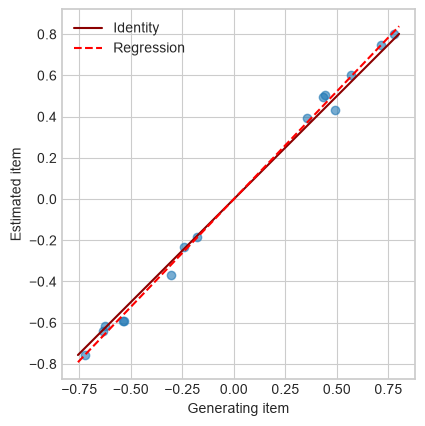

item Pearson correlation:              0.998
item SD ratio (estimated / generating): 1.048
item Regression coefficient:            1.046
item RMSE:                               0.042


In [14]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item', 'my_mfrm_centrality_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [15]:
%%time
mfrm.item_stats_df_centrality(full=True)
mfrm.item_stats_centrality.to_csv('mfrm_centrality_item_stats.csv')

CPU times: user 12.1 s, sys: 112 ms, total: 12.3 s
Wall time: 12.3 s


Check the item statistics table

In [16]:
mfrm.item_stats_centrality

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,-0.591,0.036,-0.657,-0.528,2000,0.551,0.933,-2.154,0.936,-2.052,0.694,0.690
Item_2,-0.639,0.037,-0.709,-0.568,2000,0.560,1.017,0.559,1.020,0.637,0.681,0.690
Item_3,0.392,0.035,0.324,0.462,2000,0.462,0.993,-0.198,0.994,-0.184,0.704,0.695
Item_4,-0.757,0.036,-0.826,-0.688,2000,0.568,0.929,-2.302,0.922,-2.538,0.717,0.689
Item_5,0.432,0.037,0.365,0.506,2000,0.457,1.002,0.066,1.013,0.433,0.698,0.695
Item_6,0.802,0.038,0.725,0.871,2000,0.424,0.961,-1.246,0.968,-1.003,0.699,0.694
Item_7,-0.590,0.034,-0.657,-0.528,2000,0.551,0.930,-2.244,0.924,-2.451,0.705,0.690
Item_8,-0.233,0.039,-0.309,-0.158,2000,0.521,0.978,-0.703,0.988,-0.386,0.706,0.693
Item_9,0.746,0.039,0.670,0.817,2000,0.430,0.942,-1.852,0.939,-1.966,0.713,0.694
Item_10,-0.183,0.035,-0.249,-0.114,2000,0.516,0.988,-0.375,1.001,0.031,0.714,0.693


Generate a table of threshold statistics (and check run time), and save to file

In [17]:
%%time
mfrm.threshold_stats_df_centrality(full=True)
mfrm.threshold_stats_centrality.to_csv('mfrm_centrality_threshold_stats.csv')

CPU times: user 122 ms, sys: 3.8 ms, total: 126 ms
Wall time: 127 ms


Check the threshold statistics table

In [18]:
mfrm.threshold_stats_centrality

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-4.289,0.056,-4.362,-4.136,0.936,-2.360,0.985,-0.203,1.051,0.390,0.393
Threshold 2,-2.269,0.029,-2.316,-2.204,0.989,-1.056,0.976,-1.117,1.019,0.825,0.792
Threshold 3,0.364,0.026,0.318,0.416,0.997,-0.460,0.992,-0.705,1.008,0.938,0.927
Threshold 4,1.706,0.030,1.646,1.766,0.996,-0.476,0.987,-0.783,1.010,0.855,0.838
Threshold 5,4.487,0.051,4.340,4.536,0.915,-3.366,0.854,-2.260,1.073,0.559,0.527


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

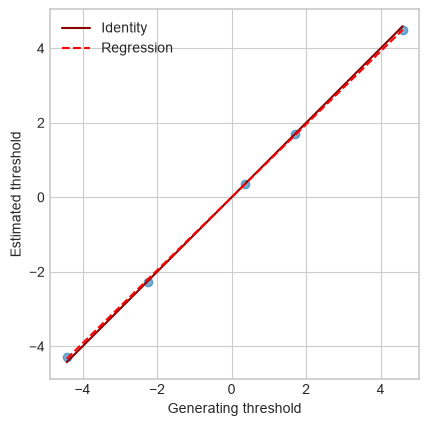

threshold Pearson correlation:              1.0
threshold SD ratio (estimated / generating): 0.98
threshold Regression coefficient:            0.979
threshold RMSE:                               0.079


In [19]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_centrality_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [20]:
%%time
mfrm.rater_stats_df_centrality()
mfrm.rater_stats_centrality.to_csv('mfrm_centrality_rater_stats.csv')
mfrm.rater_stats_centrality_full_vector.to_csv('mfrm_centrality_rater_stats_full_vector.csv')

CPU times: user 63 ms, sys: 1.84 ms, total: 64.9 ms
Wall time: 66.2 ms


Check the rater statistics table

In [21]:
mfrm.rater_stats_centrality

lambda           omega        Overall statistics                   
         Estimate     SE Estimate     SE              Count Infit MS Outfit MS
Rater_1     0.438  0.053    1.025  0.022             3000.0    0.975     0.976
Rater_2     0.392  0.056    0.982  0.024             3000.0    1.025     1.025
Rater_3    -0.602  0.064    0.955  0.028             3000.0    1.006     1.015
Rater_4     0.416  0.050    0.850  0.022             3000.0    0.966     0.970
Rater_5    -0.709  0.079    1.215  0.038             3000.0    0.969     0.970
Rater_6     0.044  0.049    0.969  0.023             3000.0    1.019     1.020
Rater_7     0.023  0.100    1.312  0.043             3000.0    0.969     0.973
Rater_8     0.550  0.045    0.866  0.020             3000.0    0.979     0.977
Rater_9    -0.991  0.048    0.759  0.024             3000.0    0.903     0.909
Rater_10    0.439  0.057    1.068  0.023             3000.0    0.962     0.959

`self.rater_stats_centrality` (above) is the model's own raw shift/stretch parameters (`lambda`, `omega`), each with its own bootstrap SE. The same call also stores the reconstructed full severity vector separately.

In [22]:
mfrm.rater_stats_centrality_full_vector

Threshold 1        Threshold 2        Threshold 3        Threshold 4  \
            Estimate     SE    Estimate     SE    Estimate     SE    Estimate   
Rater_1        0.331  0.098       0.381  0.065       0.447  0.055       0.480   
Rater_2        0.468  0.087       0.433  0.054       0.386  0.060       0.362   
Rater_3       -0.409  0.167      -0.500  0.115      -0.618  0.058      -0.679   
Rater_4        1.058  0.086       0.756  0.055       0.361  0.054       0.160   
Rater_5       -1.630  0.217      -1.196  0.150      -0.630  0.070      -0.342   
Rater_6        0.175  0.113       0.114  0.074       0.033  0.049      -0.008   
Rater_7       -1.317  0.234      -0.686  0.156       0.137  0.097       0.556   
Rater_8        1.125  0.093       0.854  0.061       0.501  0.046       0.321   
Rater_9        0.041  0.131      -0.445  0.091      -1.079  0.044      -1.402   
Rater_10       0.147  0.092       0.285  0.061       0.463  0.060       0.554   

                Threshold 5        Overall statistics                     
             SE    Estimate     SE              Count Infit MS Outfit MS  
Rater_1   0.071       0.549  0.121             3000.0    0.975     0.976  
Rater_2   0.083       0.313  0.141             3000.0    1.025     1.025  
Rater_3   0.048      -0.804  0.095             3000.0    1.006     1.015  
Rater_4   0.073      -0.257  0.122             3000.0    0.966     0.970  
Rater_5   0.060       0.255  0.129             3000.0    0.969     0.970  
Rater_6   0.061      -0.093  0.112             3000.0    1.019     1.020  
Rater_7   0.108       1.425  0.193             3000.0    0.969     0.973  
Rater_8   0.057      -0.051  0.101             3000.0    0.979     0.977  
Rater_9   0.042      -2.071  0.087             3000.0    0.903     0.909  
Rater_10  0.080       0.743  0.134             3000.0    0.962     0.959

The two parameters themselves `lambda_centrality` (severity shift) and `omega_centrality` (threshold stretch) are the two parameters the model produces per rater – `mfrm.raters_centrality` above is just their reconstruction back into full (rater x threshold) form, for compatibility with all the same downstream fit-statistic and plotting machinery the other rater parameterisations use. The term `lambda` is used for the global severity since it is an additive parameter, as for instance in the `thresholds` model, so `lambda` is consistent with the notation used elsewhere in the package. `omega` is used for the stretch parameter, following Jin & Wang (2018)'s own notation for a rater stretch factor – it is a multiplicative parameter rather than an additive one, so has a distinct Greek letter to distinguish it from from the additive shift. A rater near `omega=1` is showing undistorted category-width perceptions; well above 1 is central tendency (or restricted range); well below 1 is extreme tendency.

In [23]:
pd.DataFrame({'lambda (severity)': mfrm.lambda_centrality, 'omega (stretch)': mfrm.omega_centrality}).round(3)

,lambda (severity),omega (stretch)
Rater_1,0.438,1.025
Rater_2,0.392,0.982
Rater_3,-0.602,0.955
Rater_4,0.416,0.850
Rater_5,-0.709,1.215
Rater_6,0.044,0.969
Rater_7,0.023,1.312
Rater_8,0.550,0.866
Rater_9,-0.991,0.759
Rater_10,0.439,1.068


Pass `alias=True` to `rater_stats_df_centrality()` to relabel these columns with a human-readable name instead of the raw parameter name – `'Global'` for `lambda`, `'Threshold stretch'` for `omega`. Purely cosmetic, values remain unchanged:

In [24]:
mfrm.rater_stats_df_centrality(alias=True)
mfrm.rater_stats_centrality

Global        Threshold stretch        Overall statistics           \
         Estimate     SE          Estimate     SE              Count Infit MS   
Rater_1     0.438  0.053             1.025  0.022             3000.0    0.975   
Rater_2     0.392  0.056             0.982  0.024             3000.0    1.025   
Rater_3    -0.602  0.064             0.955  0.028             3000.0    1.006   
Rater_4     0.416  0.050             0.850  0.022             3000.0    0.966   
Rater_5    -0.709  0.079             1.215  0.038             3000.0    0.969   
Rater_6     0.044  0.049             0.969  0.023             3000.0    1.019   
Rater_7     0.023  0.100             1.312  0.043             3000.0    0.969   
Rater_8     0.550  0.045             0.866  0.020             3000.0    0.979   
Rater_9    -0.991  0.048             0.759  0.024             3000.0    0.903   
Rater_10    0.439  0.057             1.068  0.023             3000.0    0.962   

                    
         Outfit MS  
Rater_1      0.976  
Rater_2      1.025  
Rater_3      1.015  
Rater_4      0.970  
Rater_5      0.970  
Rater_6      1.020  
Rater_7      0.973  
Rater_8      0.977  
Rater_9      0.909  
Rater_10     0.959

To add an item-by-item divergence test comparing `centrality`'s vector reconstruction against `thresholds`' own free per-item estimates to see which rater-threshold combinations, if any, show significant deviation from the uniform threshold stretching pattern and then inspect the per-rater flagged items and total count:

`divergence_test='wald'` references the test statistic against the standard normal distribution; `divergence_test='t'` uses a plain Student's t-distribution with `no_of_samples - 1` degrees of freedom instead, correcting (a little) for finite-bootstrap-sample uncertainty in the SE estimate itself. In practice `'t'` is only relevant when `no_of_samples` has deliberately been dropped for speed – at `no_of_samples=300` or more, `'wald'` and `'t'` give essentially the same p-values. With a larger `no_of_samples`, there is no reason to prefer `'t'` over `'wald'`.

Passing `full=True` adds one plain True/False column per threshold to the primary table itself, directly after the `'Flagged categories'` count, for scanning flagged status across all elements at a glance – and `rater_stats_centrality_full_vector` receives a per-element `'Flagged'` column added to each threshold's own `Estimate`/`SE`/CI block displaying the same information alongside. The full `mfrm.rater_stats_centrality` is displayed here transposed using `.T` for visual convenience.

In [25]:
mfrm.rater_stats_df_centrality(full=True, divergence_test='wald', correction='bh')
mfrm.rater_stats_centrality.T

Rater_1 Rater_2 Rater_3 Rater_4 Rater_5 Rater_6  \
lambda             Estimate    0.438   0.392  -0.602   0.416  -0.709   0.044   
                   SE          0.052   0.059   0.069   0.051   0.075   0.053   
                   2.5%        0.353   0.257  -0.743   0.321  -0.862  -0.063   
                   97.5%       0.553   0.491  -0.473   0.519  -0.563   0.148   
omega              Estimate    1.025   0.982   0.955    0.85   1.215   0.969   
                   SE          0.023   0.024    0.03   0.022   0.036   0.023   
                   2.5%         0.98   0.931   0.902   0.802   1.149   0.919   
                   97.5%       1.068   1.028   1.015   0.889   1.281    1.01   
Flagged categories Count         0.0     0.0     0.0     0.0     0.0     0.0   
Threshold 1        Flagged     False   False   False   False   False   False   
Threshold 2        Flagged     False   False   False   False   False   False   
Threshold 3        Flagged     False   False   False   False   False   False   
Threshold 4        Flagged     False   False   False   False   False   False   
Threshold 5        Flagged     False   False   False   False   False   False   
Overall statistics Count      3000.0  3000.0  3000.0  3000.0  3000.0  3000.0   
                   Infit MS    0.975   1.025   1.006   0.966   0.969   1.019   
                   Infit Z    -0.977   0.981    0.23   -1.33  -1.248   0.758   
                   Outfit MS   0.976   1.025   1.015    0.97    0.97    1.02   
                   Outfit Z   -0.923   0.957   0.608  -1.176  -1.156   0.771   

                             Rater_7 Rater_8 Rater_9 Rater_10  
lambda             Estimate    0.023    0.55  -0.991    0.439  
                   SE          0.099   0.047   0.052    0.054  
                   2.5%       -0.197   0.462  -1.099     0.36  
                   97.5%       0.188   0.634  -0.907    0.575  
omega              Estimate    1.312   0.866   0.759    1.068  
                   SE           0.04   0.018   0.023    0.023  
                   2.5%         1.26   0.828   0.712     1.03  
                   97.5%        1.41   0.901   0.799    1.118  
Flagged categories Count         0.0     0.0     0.0      0.0  
Threshold 1        Flagged     False   False   False    False  
Threshold 2        Flagged     False   False   False    False  
Threshold 3        Flagged     False   False   False    False  
Threshold 4        Flagged     False   False   False    False  
Threshold 5        Flagged     False   False   False    False  
Overall statistics Count      3000.0  3000.0  3000.0   3000.0  
                   Infit MS    0.969   0.979   0.903    0.962  
                   Infit Z    -1.184  -0.823  -3.927   -1.478  
                   Outfit MS   0.973   0.977   0.909    0.959  
                   Outfit Z    -0.98  -0.909  -3.564    -1.58

Recovery check on `mfrm.generating.lambda_`/`mfrm.generating.omega`. Plotted separately since they are on different scales:

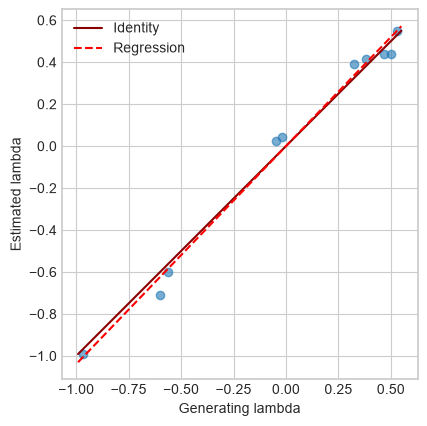

lambda Pearson correlation:              0.995
lambda SD ratio (estimated / generating): 1.045
lambda Regression coefficient:            1.039
lambda RMSE:                               0.058


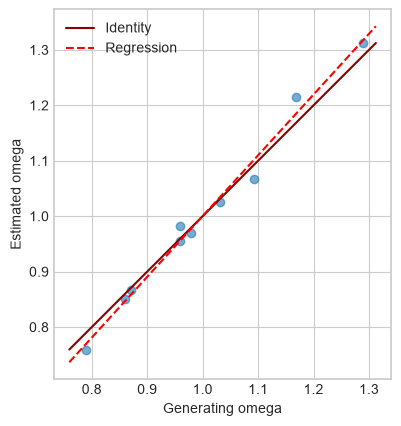

omega Pearson correlation:              0.994
omega SD ratio (estimated / generating): 1.103
omega Regression coefficient:            1.096
omega RMSE:                               0.022


In [26]:
recovery_plot(mfrm.generating.lambda_, mfrm.lambda_centrality, 'lambda', 'my_mfrm_centrality_lambda_recovery.png')
recovery_plot(mfrm.generating.omega, mfrm.omega_centrality, 'omega', 'my_mfrm_centrality_omega_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [27]:
%%time
mfrm.person_stats_df_centrality(full=True)
mfrm.person_stats_centrality.to_csv('mfrm_centrality_person_stats.csv')

CPU times: user 14.8 ms, sys: 916 μs, total: 15.8 ms
Wall time: 15.7 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [28]:
mfrm.person_stats_centrality.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,-0.581,0.120,0.109,328,750,0.437,0.830,0.809,-1.444,-1.624
Person_2,0.001,0.116,0.124,370,750,0.493,1.139,1.161,1.187,1.348
Person_3,-0.039,0.116,0.126,367,750,0.489,1.170,1.217,1.422,1.769
Person_4,1.042,0.112,0.114,451,750,0.601,1.040,1.036,0.405,0.374
Person_5,3.243,0.135,0.119,604,750,0.805,0.778,0.773,-1.894,-1.944
Person_6,-1.546,0.123,0.129,263,750,0.351,1.103,1.061,0.858,0.534
Person_7,-1.714,0.123,0.115,252,750,0.336,0.867,0.854,-1.116,-1.237
Person_8,-1.244,0.123,0.140,283,750,0.377,1.305,1.321,2.299,2.397
Person_9,2.420,0.122,0.121,554,750,0.739,0.971,0.952,-0.216,-0.374
Person_10,0.866,0.112,0.114,437,750,0.583,1.034,1.039,0.353,0.396


And the same recovery check for person locations, against `mfrm.generating.persons`:

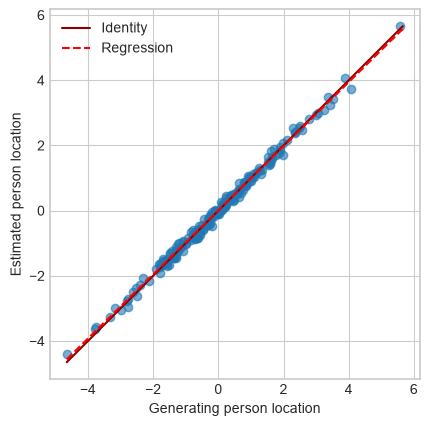

person location Pearson correlation:              0.997
person location SD ratio (estimated / generating): 0.986
person location Regression coefficient:            0.983
person location RMSE:                               0.115


In [29]:
recovery_plot(mfrm.generating.persons, mfrm.persons_centrality, 'person location', 'my_mfrm_centrality_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [30]:
%%time
mfrm.test_stats_df_centrality()
mfrm.test_stats_centrality.to_csv('mfrm_centrality_test_stats.csv')

CPU times: user 2.82 ms, sys: 560 μs, total: 3.38 ms
Wall time: 3.33 ms


Check the test statistics table

In [31]:
mfrm.test_stats_centrality

,Items,Persons
Mean,0.000,0.009
SD,0.579,1.537
Separation ratio,15.662,12.946
Strata,21.216,17.595
Reliability,0.996,0.994


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [32]:
%%time
mfrm.item_res_corr_analysis_centrality()
mfrm.item_residual_correlations_centrality.to_csv('mfrm_centrality_item_residual_correlations.csv')
mfrm.item_loadings_centrality.to_csv('mfrm_centrality_item_loadings.csv')

CPU times: user 7.74 ms, sys: 2.59 ms, total: 10.3 ms
Wall time: 14.7 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [33]:
round(mfrm.item_residual_correlations_centrality, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12,Item_13,Item_14,Item_15
Item_1,1.000,-0.015,-0.018,-0.044,-0.014,0.014,-0.033,0.046,-0.016,-0.036,-0.019,0.029,-0.027,0.027,0.004
Item_2,-0.015,1.000,-0.037,0.024,0.005,-0.030,-0.022,-0.013,-0.031,-0.009,0.011,0.037,-0.021,-0.020,0.035
Item_3,-0.018,-0.037,1.000,-0.037,0.009,-0.035,0.014,0.009,0.011,-0.031,-0.013,0.024,0.014,-0.021,0.018
Item_4,-0.044,0.024,-0.037,1.000,0.032,0.025,0.011,-0.046,-0.038,0.038,0.026,-0.004,-0.041,0.006,-0.039
Item_5,-0.014,0.005,0.009,0.032,1.000,0.006,-0.016,0.015,-0.009,0.014,-0.043,0.001,0.025,0.005,-0.015
Item_6,0.014,-0.030,-0.035,0.025,0.006,1.000,-0.003,-0.034,-0.036,-0.049,-0.061,-0.016,-0.002,0.009,0.004
Item_7,-0.033,-0.022,0.014,0.011,-0.016,-0.003,1.000,-0.028,0.013,-0.034,0.009,-0.000,-0.032,-0.016,-0.031
Item_8,0.046,-0.013,0.009,-0.046,0.015,-0.034,-0.028,1.000,-0.052,-0.011,-0.018,-0.009,-0.028,0.043,-0.014
Item_9,-0.016,-0.031,0.011,-0.038,-0.009,-0.036,0.013,-0.052,1.000,-0.008,-0.031,0.012,-0.011,-0.007,0.021
Item_10,-0.036,-0.009,-0.031,0.038,0.014,-0.049,-0.034,-0.011,-0.008,1.000,-0.007,-0.071,-0.009,-0.002,-0.024


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [34]:
round(mfrm.item_loadings_centrality['PC 1'], 3)

Item_1    -0.104
Item_2     0.037
Item_3    -0.087
Item_4     0.174
Item_5     0.051
Item_6     0.015
Item_7     0.024
Item_8    -0.064
Item_9    -0.048
Item_10    0.141
Item_11    0.035
Item_12   -0.091
Item_13   -0.026
Item_14   -0.005
Item_15   -0.077
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [35]:
%%time
mfrm.rater_res_corr_analysis_centrality()
mfrm.rater_residual_correlations_centrality.to_csv('mfrm_centrality_rater_residual_correlations.csv')
mfrm.rater_loadings_centrality.to_csv('mfrm_centrality_rater_loadings.csv')

CPU times: user 15.1 ms, sys: 667 μs, total: 15.8 ms
Wall time: 15.7 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [36]:
round(mfrm.rater_residual_correlations_centrality, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8,Rater_9,Rater_10
Rater_1,1.000,0.008,0.026,-0.003,-0.013,-0.015,0.001,0.009,-0.004,-0.044
Rater_2,0.008,1.000,0.022,-0.013,0.006,0.002,-0.040,0.011,-0.003,-0.010
Rater_3,0.026,0.022,1.000,-0.025,0.003,0.027,0.024,-0.025,-0.022,-0.033
Rater_4,-0.003,-0.013,-0.025,1.000,-0.004,0.001,0.049,0.025,-0.004,-0.014
Rater_5,-0.013,0.006,0.003,-0.004,1.000,-0.005,-0.003,-0.020,-0.003,-0.005
Rater_6,-0.015,0.002,0.027,0.001,-0.005,1.000,-0.009,-0.001,0.009,-0.009
Rater_7,0.001,-0.040,0.024,0.049,-0.003,-0.009,1.000,0.002,0.002,-0.029
Rater_8,0.009,0.011,-0.025,0.025,-0.020,-0.001,0.002,1.000,-0.024,-0.010
Rater_9,-0.004,-0.003,-0.022,-0.004,-0.003,0.009,0.002,-0.024,1.000,-0.024
Rater_10,-0.044,-0.010,-0.033,-0.014,-0.005,-0.009,-0.029,-0.010,-0.024,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [37]:
round(mfrm.rater_loadings_centrality['PC 1'], 3)

Rater_1     0.042
Rater_2    -0.154
Rater_3    -0.048
Rater_4     0.176
Rater_5    -0.092
Rater_6    -0.061
Rater_7     0.198
Rater_8     0.066
Rater_9     0.016
Rater_10   -0.120
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

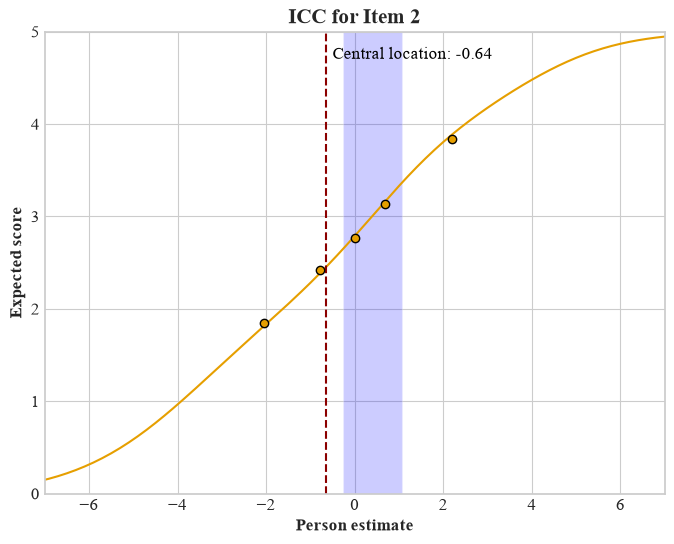

In [38]:
mfrm.icc_centrality('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_centrality_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

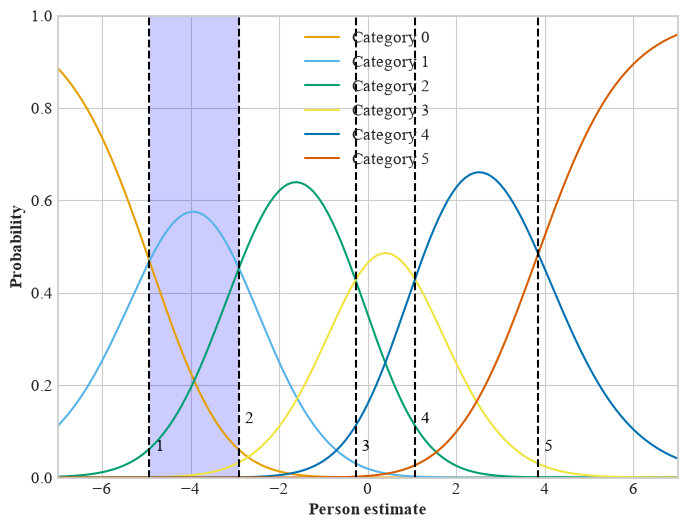

In [39]:
mfrm.crcs_centrality('Item_2', thresh_lines=True, cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_centrality_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

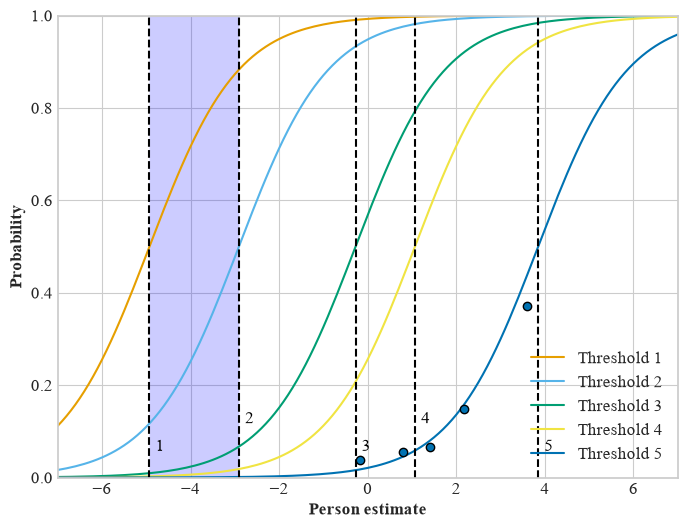

In [40]:
mfrm.threshold_ccs_centrality('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_centrality_threshold_ccs')

Produce an item information function curve for Item 2

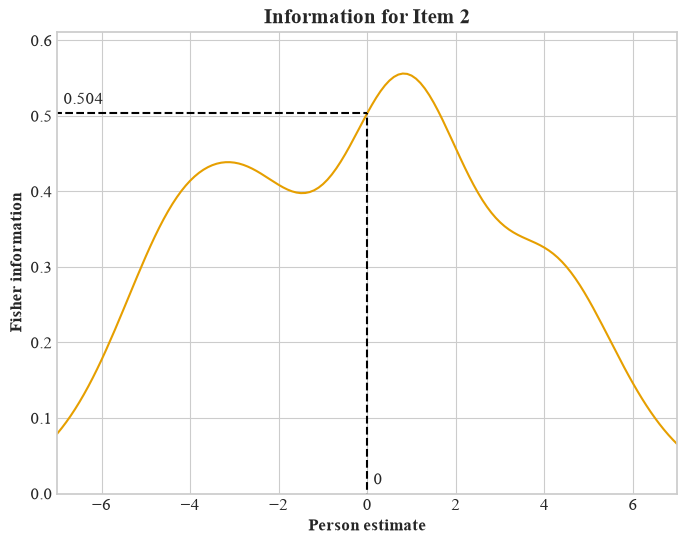

In [41]:
mfrm.iic_centrality('Item_2', point_info_lines=[0], point_info_labels=True,
                    title='Information for Item 2', xmin=-7, xmax=7, filename='my_mfrm_centrality_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

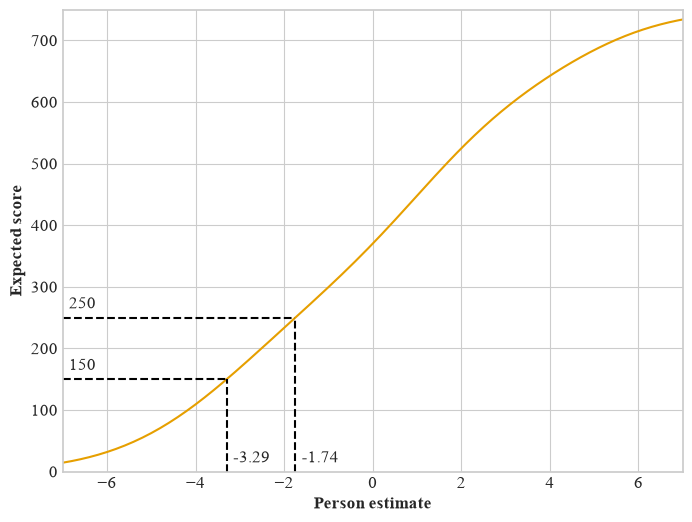

In [42]:
mfrm.tcc_centrality(score_lines=[150, 250], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_centrality_tcc')

Produce a test information curve

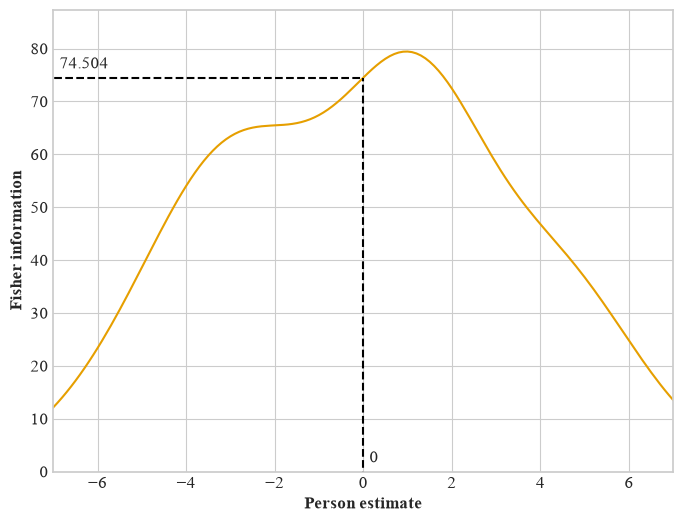

In [43]:
mfrm.test_info_centrality(point_info_lines=[0], point_info_labels=True,
                          xmin=-7, xmax=7, filename='my_mfrm_centrality_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

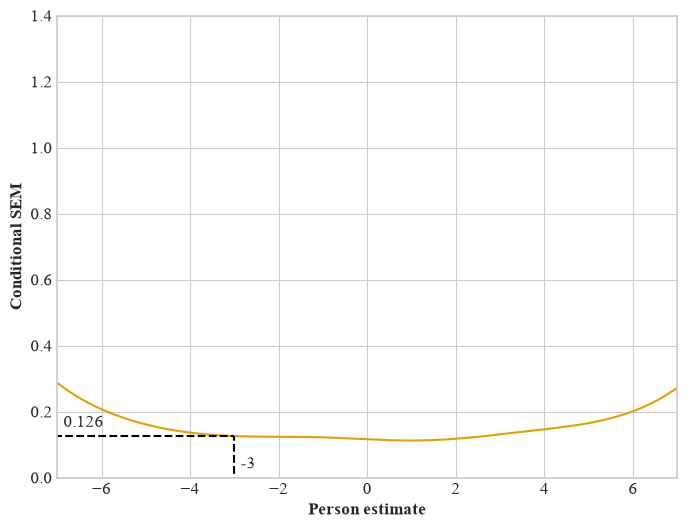

In [44]:
mfrm.test_csem_centrality(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_centrality_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

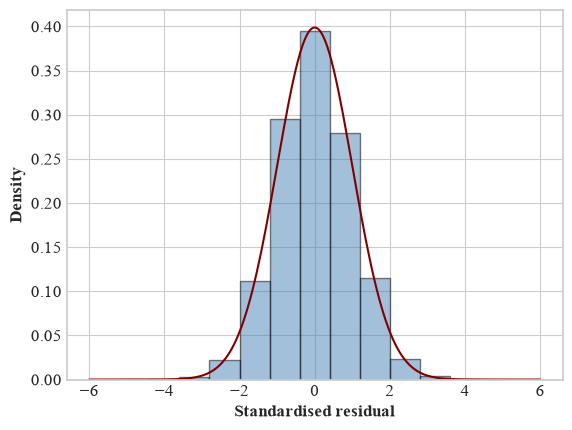

In [45]:
mfrm.std_residuals_plot_centrality(bin_width=0.6, normal=True, filename='my_mfrm_centrality_std_residuals_plot')

**Model selection.** Since `centrality` is nested between `global` and `thresholds`, `model_selection()` can compare it against all eight MFRM rater representations (or a chosen subset via `models=`) directly via AIC, BIC, or LR. See the `Model selection` example notebook for a full worked demonstration, including a direct three-way comparison of the stretch representations (`models=['centrality', 'pseudo_halo', 'bistretch']`).

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [46]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_centrality_anchor(anchors)

CPU times: user 23.3 ms, sys: 3.88 ms, total: 27.2 ms
Wall time: 23.8 ms


Check the anchored thresholds against the unanchored thresholds

In [47]:
threshold_check = pd.DataFrame({'Unanchored': mfrm.thresholds,
                           'Anchored': mfrm.anchor_thresholds_centrality})
round(threshold_check, 3)

,Unanchored,Anchored
1,-4.289,-4.093
2,-2.269,-2.168
3,0.364,0.373
4,1.706,1.630
5,4.487,4.259


Check the anchored rater x threshold severities against the unanchored ones (two separate dataframes).

In [48]:
round(mfrm.raters_centrality, 3)

,1,2,3,4,5
Rater_1,0.331,0.381,0.447,0.480,0.549
Rater_2,0.468,0.433,0.386,0.362,0.313
Rater_3,-0.409,-0.500,-0.618,-0.679,-0.804
Rater_4,1.058,0.756,0.361,0.160,-0.257
Rater_5,-1.630,-1.196,-0.630,-0.342,0.255
Rater_6,0.175,0.114,0.033,-0.008,-0.093
Rater_7,-1.317,-0.686,0.137,0.556,1.425
Rater_8,1.125,0.854,0.501,0.321,-0.051
Rater_9,0.041,-0.445,-1.079,-1.402,-2.071
Rater_10,0.147,0.285,0.463,0.554,0.743


In [49]:
round(mfrm.anchor_raters_centrality, 3)

,1,2,3,4,5
Rater_1,-0.033,0.110,0.299,0.393,0.588
Rater_2,0.107,0.166,0.245,0.284,0.366
Rater_3,-0.772,-0.768,-0.764,-0.762,-0.757
Rater_4,0.689,0.484,0.214,0.080,-0.199
Rater_5,-1.994,-1.464,-0.763,-0.417,0.307
Rater_6,-0.185,-0.152,-0.107,-0.085,-0.038
Rater_7,-1.679,-0.952,0.008,0.483,1.477
Rater_8,0.764,0.588,0.357,0.242,0.003
Rater_9,-0.319,-0.709,-1.224,-1.479,-2.012
Rater_10,-0.210,0.024,0.332,0.485,0.804


Produce a Wright map (unanchored), showing the person location distribution alongside an item strip and a rater panel (severity shift, lambda), plus a stretch panel showing each rater's centrality/extremity multiplier (omega), with mean/±1SD/±2SD reference marks for persons

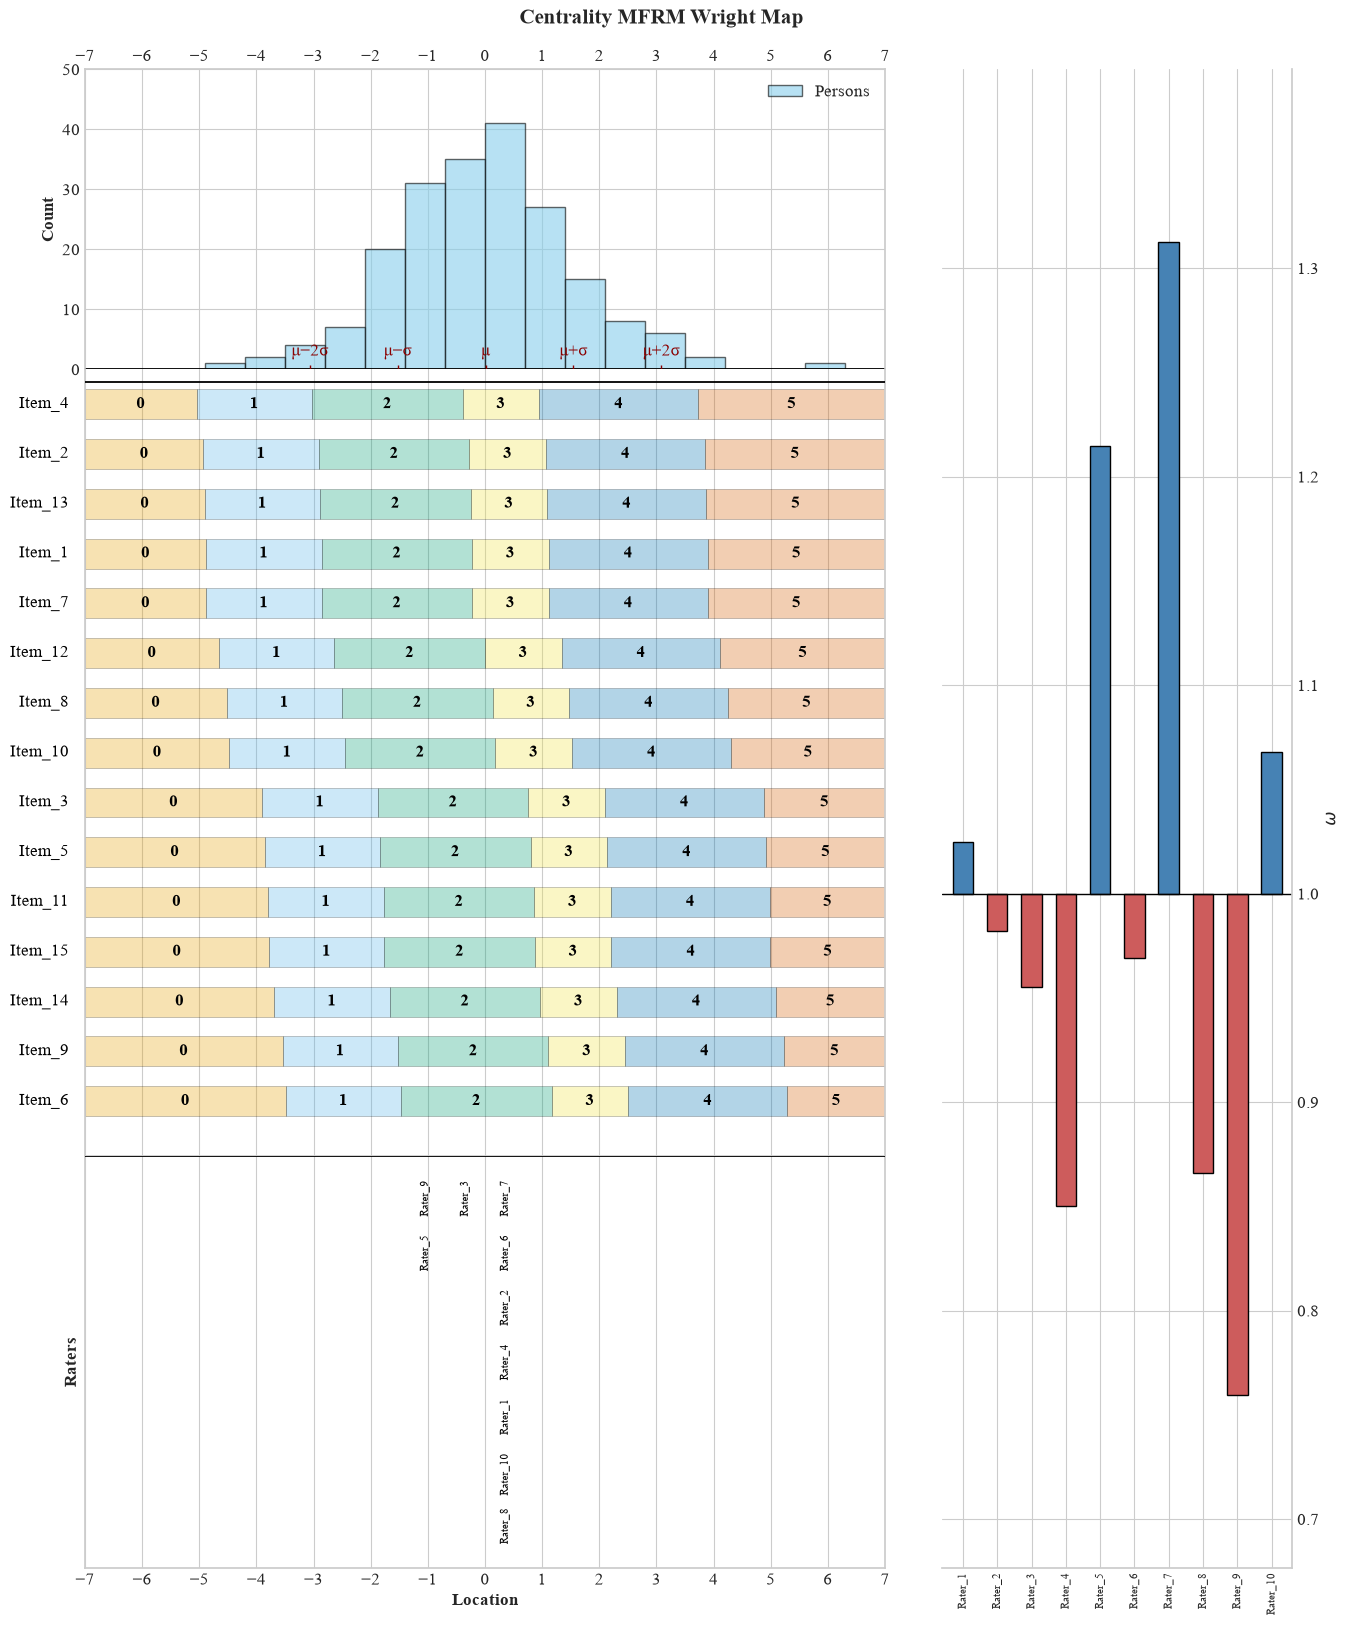

In [50]:
mfrm.wright_map_centrality(item_strip=True, facet_labels=True, show_stretch=True, distribution_markers=True, title='Centrality MFRM Wright Map', filename='my_mfrm_centrality_wright_map')